# compute and save the distances between heads using the embeddings

embeddings of patterns in PCA space from notebook 02

In [1]:
from pathlib import Path

import muutils.tensor_info
import polars as pl
from muutils.dbg import dbg_tensor

# attention-motifs
from attn_embed.attnpedia.attnpedia import AttentionPedia
from attn_embed.features.analysis import (
	DistanceTensorResult,
)

In [2]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

# load data

In [3]:
DF_PCA: pl.DataFrame = pl.read_ndjson(PATH_BASE / "pca.jsonl")

# distances between heads

In [4]:
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.build_distance_tensor(
	DF_PCA,
	feature_prefix="pc.",
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
HEAD_DISTS.save(PATH_BASE / "head_dists.zanj")

prompts: 100%|██████████| 16/16 [00:00<00:00, 94.23it/s]
[ <ipykernel>:5 ] HEAD_DISTS.distances: μ=10.39 σ=4.74 x̃=9.75 R=[0.00,32.18] ℙ=|▁█▇▃   | shape=(272,272,16) dtype=float64
[ <ipykernel>:6 ] HEAD_DISTS.mean_dists: μ=10.39 σ=4.40 x̃=9.64 R=[0.00,29.50] ℙ=| ▇█▄▁  | shape=(272,272) dtype=float64


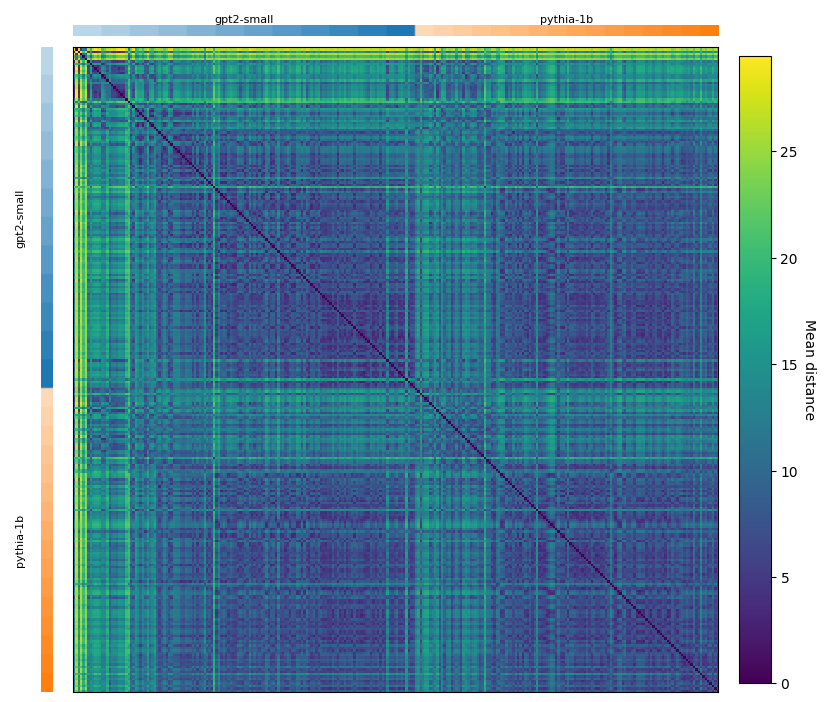

In [5]:
fig = HEAD_DISTS.plot_heatmap(show=False)
fig.savefig(
	"figures/head-dists-heatmap.pdf",
	bbox_inches="tight",
	pad_inches=0.1,
)

# attentionpedia

In [6]:
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

In [7]:
HEAD_DISTS.get_closest_heads("gpt2-small:L5:H5", n_closest=10)
# 'gpt2-medium:L5:H8

# for k in HEAD_DISTS.cls_values:
# 	plt.plot(
# 		[
# 			x[1]
# 			for x in HEAD_DISTS.get_closest_heads(k, n_closest=50)[1:]
# 		],
# 		alpha=0.05,
# 		color="black",
# 	)

# plt.show()

[('gpt2-small:L5:H5', 0.0),
 ('pythia-1b:L5:H7', 3.759347005483217),
 ('gpt2-small:L5:H0', 3.862127139467549),
 ('pythia-1b:L11:H7', 3.9964763019881984),
 ('gpt2-small:L10:H1', 4.0101614442460445),
 ('pythia-1b:L4:H4', 4.184183506502164),
 ('pythia-1b:L6:H7', 4.266034885811444),
 ('pythia-1b:L7:H0', 4.2921006586041415),
 ('gpt2-small:L3:H0', 4.416179998302718),
 ('gpt2-small:L9:H9', 4.45637405166604)]

In [8]:
# HEAD_DISTS.plot_hists(n_samples=64)